#**AGEN/BSEN 892 AI & Visual Intelligence in Smart Agriculture**
#**Week 5. Machine Learning II - Logstic Regression & Support Vector Machine**
<br/>


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#**Logistic Regression**

##Data visualization

In [25]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt

# Some functions to plot our points and draw the lines
def plot_points(features, labels,size = 100):
    X = np.array(features)
    y = np.array(labels)
    class1 = X[np.argwhere(y==1)]
    class2 = X[np.argwhere(y==0)]
    plt.scatter([s[0][0] for s in class1],
                   [s[0][1] for s in class1],
                   s = size,
                   color = 'cyan',
                   edgecolor = 'k',
                   marker = '^')
    plt.scatter([s[0][0] for s in class2],
                   [s[0][1] for s in class2],
                   s = size,
                   color = 'red',
                   edgecolor = 'k',
                   marker = 's')
    plt.xlabel('feature 1')
    plt.ylabel('feature 2')
    plt.legend(['class1','class2'])


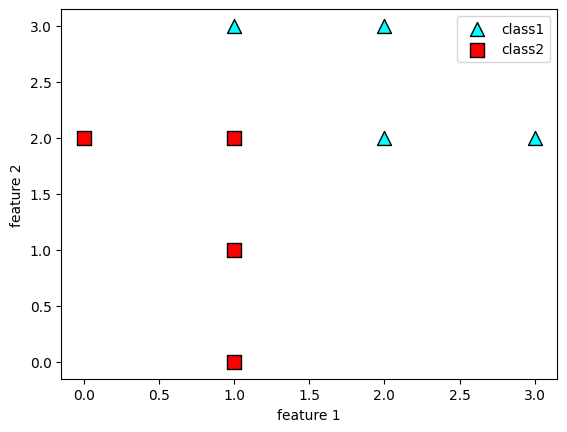

In [26]:
import numpy as np
features = np.array([[1,0],[0,2],[1,1],[1,2],[1,3],[2,2],[3,2],[2,3]])
labels = np.array([0,0,0,0,1,1,1,1])
plot_points(features, labels)

##Binary Logistic Regression from scratch

Final weights:
 [[-5.66778658]
 [ 2.23944733]
 [ 1.52159885]]

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8

Confusion Matrix:
 [[4 0]
 [0 4]]
Log Loss: 0.15417089543296827


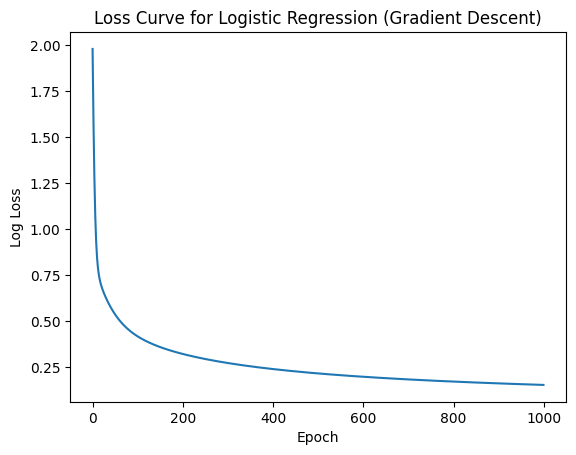

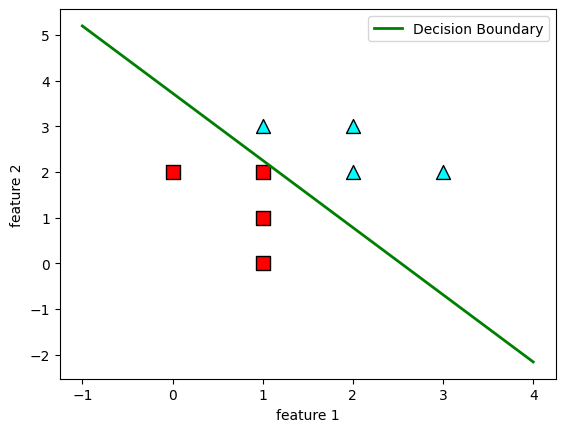

In [27]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss
# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Add bias term
feature_bias = np.hstack([np.ones((features.shape[0], 1)), features])

# Initialize weights
weights = np.random.randn(features.shape[1]+1, 1)
# print("weights shape:", weights.shape)

# reshape from 1D (n,) to 2D column vector (n, 1)
labels = labels.reshape(-1,1)
loss_history = []

# Hyperparameters
epochs = 1000
lr = 0.1
m = features.shape[0]  # number of samples

# Gradient Descent
for epoch in range(epochs):
    z = np.dot(feature_bias, weights)   # same as feature_bias @ weights
    y_hat = sigmoid(z)

    # Gradient descent to update weights
    gradient = np.dot(feature_bias.T, (y_hat - labels)) / m
    weights -= lr * gradient

    # Compute loss
    loss = -np.mean(labels*np.log(y_hat+1e-9) + (1-labels)*np.log(1-y_hat+1e-9)) # avoid log0
    loss_history.append(loss)

    # Print loss every 200 iterations
    # if epoch % 200 == 0:
    #     loss = -np.mean(labels*np.log(y_hat+1e-9) + (1-labels)*np.log(1-y_hat+1e-9))
    #     print(f"Epoch {epoch}, Loss: {loss:.4f}")

print("Final weights:\n", weights)

predicted_probs = sigmoid(np.dot(feature_bias, weights)) # probabilities
predicted_labels = (predicted_probs >= 0.5).astype(int) # predictions using 0.5 as the threshold

# Metrics
print("\nAccuracy:", accuracy_score(labels, predicted_labels)) # accuracy: correct predictions/total number of samples
print("\nClassification Report:\n", classification_report(labels, predicted_labels))
print("Confusion Matrix:\n", confusion_matrix(labels, predicted_labels))
print("Log Loss:", log_loss(labels, predicted_probs))

# Plot loss curve
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Loss Curve for Logistic Regression (Gradient Descent)")
plt.show()

# Plot points
plot_points(features, labels)

# Plot decision boundary: w0 + w1*x1 + w2*x2 = 0
x_values = np.linspace(features[:,0].min()-1, features[:,0].max()+1, 100)
y_values = -(weights[0] + weights[1]*x_values) / weights[2]

plt.plot(x_values, y_values, 'g', linewidth=2, label="Decision Boundary")
plt.legend()
plt.show()

<font size=5> Common Evaluation Metrics:https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/  <br>
Confusion Matrix:
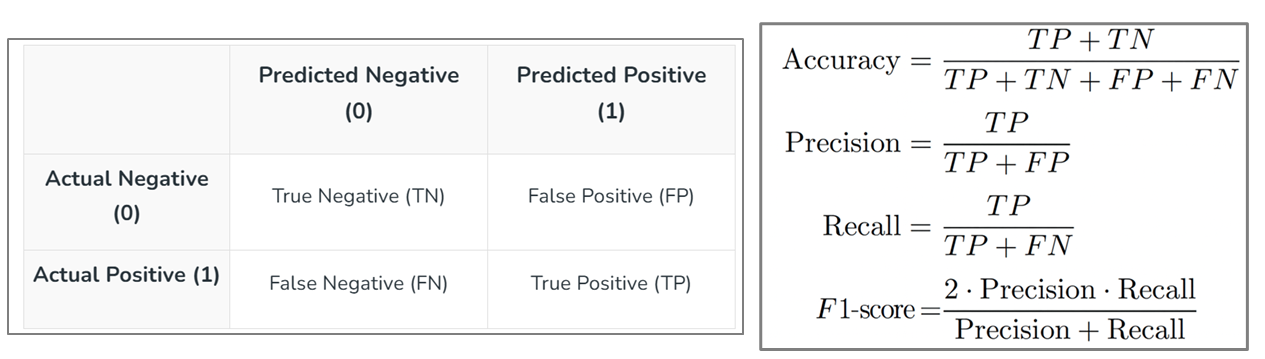

**True Positive (TP)**: The model predicted positive, and the actual label was also positive.<br>
**False Positive (FP)**: The model predicted positive, but the actual label was negative.<br>
**False Negative (FN)**: The model predicted negative, but the actual label was positive.<br>
**True Negative (TN)**: The model predicted negative, and the actual label was also negative.<br>
<br>
**Classification Report**:<br>
Support: The number of actual samples for each class.<br>
Accuracy: overall correctness across all classes.<br>
Macro avg: average of each metric across all classes equally.<br>
Weighted avg: average weighted by support. (larger classes count more).<br>


##Binary Logistic Regression using scikit-learn package

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8

Confusion Matrix:
 [[4 0]
 [0 4]]
Log Loss: 0.29076430173565654


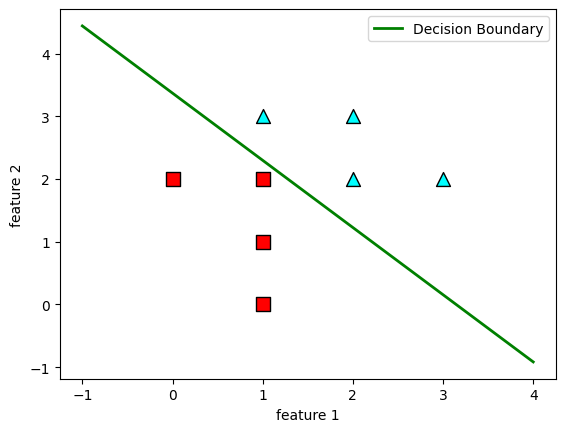

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss

labels = labels.astype(int).ravel()

# Exercise to use logistic regression package
# Train binary logistic regression
logistic_regression = LogisticRegression(solver="lbfgs", fit_intercept=True, C = 1.0)
logistic_regression.fit(features, labels)

# Prediced labels and probabilities
predicted_labels = logistic_regression.predict(features)
predicted_probs = logistic_regression.predict_proba(features)

# Metrics
print("Accuracy:", accuracy_score(labels, predicted_labels))
print("\nClassification Report:\n", classification_report(labels, predicted_labels))
print("Confusion Matrix:\n", confusion_matrix(labels, predicted_labels))
print("Log Loss:", log_loss(labels, predicted_probs))

# Plot points
plot_points(features, labels)

#Plot decision boundary: w0 + w1*x1 + w2*x2 = 0 → x2 = -(w0 + w1*x1)/w2
x_values = np.linspace(features[:,0].min()-1, features[:,0].max()+1, 100)
y_values = -(logistic_regression.intercept_[0] + logistic_regression.coef_[0][0]*x_values) / logistic_regression.coef_[0][1]

plt.plot(x_values, y_values, 'g', linewidth=2, label="Decision Boundary")
plt.legend()
plt.show()

##Multinomial Logistic Regression

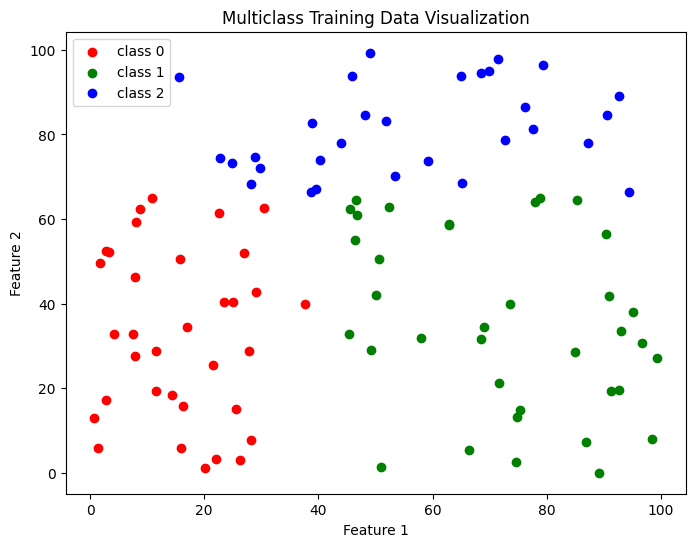

In [29]:
import pandas as pd

#load data as numpy array using genfromtxt
multi_class_data = np.array(pd.read_csv('/content/drive/MyDrive/AGST 892/Week5/multi-class.csv'))

#number of samples
m = multi_class_data.shape[0]

#input(Features) last column is the output column so slicing the train_data based on that
X = multi_class_data[:,:-1]
y = multi_class_data[:,-1:]

#As we are using vector implementation adding a column in X with all the value 1
X_bias = np.hstack((np.ones((m,1)),X))

plt.figure(figsize=(8,6))
plt.scatter(X_bias[y[:,0] == 0][:,1], X_bias[y[:,0] == 0][:,2], label='class 0', c='r')
plt.scatter(X_bias[y[:,0] == 1][:,1], X_bias[y[:,0] == 1][:,2], label='class 1', c='g')
plt.scatter(X_bias[y[:,0] == 2][:,1], X_bias[y[:,0] == 2][:,2], label='class 2', c='b')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Multiclass Training Data Visualization")
plt.legend()
plt.show()

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        34
           1       1.00      1.00      1.00        36
           2       1.00      1.00      1.00        30

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

Confusion Matrix:
 [[34  0  0]
 [ 0 36  0]
 [ 0  0 30]]
Log Loss: 0.016457379749875035


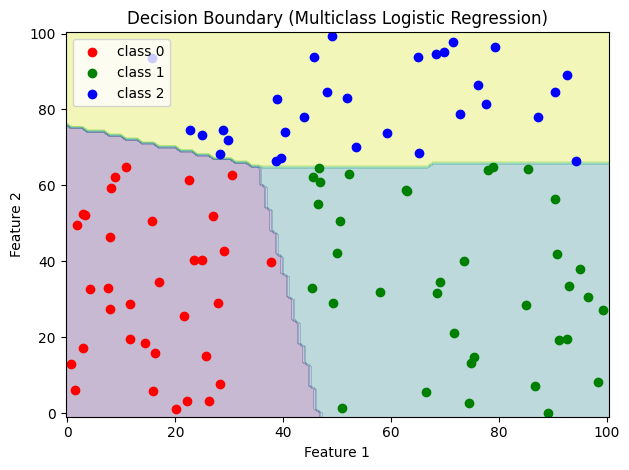

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import DecisionBoundaryDisplay

y = y.astype(int).ravel()

# Exercise to use multinomial logistic regression package
# Train multinomial logistic regression
clf = LogisticRegression() #########insert perameter
clf.fit(X, y)

# Predictions
predictions_labels = clf.predict(X)
predicted_probs = clf.predict_proba(X)

# Metrics
print("Accuracy:", accuracy_score(y, predictions_labels))
print("\nClassification Report:\n", classification_report(y, predictions_labels))
print("Confusion Matrix:\n", confusion_matrix(y, predictions_labels))
print("Log Loss:", log_loss(y, predicted_probs))

# Plot decision boundary with DecisionBoundaryDisplay
disp = DecisionBoundaryDisplay.from_estimator(
    clf, # trained model
    X, # input features
    response_method="predict", # plot regions by class assignment - clf.predict(X)
    alpha=0.3, # transparency level for the decision region background
    xlabel="Feature 1",
    ylabel="Feature 2"
)

# Scatter the data points
disp.ax_.scatter(X[y == 0][:, 0], X[y == 0][:, 1], c='r', label="class 0")
disp.ax_.scatter(X[y == 1][:, 0], X[y == 1][:, 1], c='g', label="class 1")
disp.ax_.scatter(X[y == 2][:, 0], X[y == 2][:, 1], c='b', label="class 2")

disp.ax_.set_title("Decision Boundary (Multiclass Logistic Regression)")
disp.ax_.legend()
plt.tight_layout()
plt.show()

#**Support Vector Machine**

##Data visualization

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_model(X, y, model):
    X = np.array(X)
    y = np.array(y)
    plot_step = 0.01
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z,colors = 'k',linewidths = 3)
    plot_points(X, y,size = 25)
    plt.contourf(xx, yy, Z, colors=['red', 'blue'], alpha=0.2, levels=range(-1,2))
    plt.show()

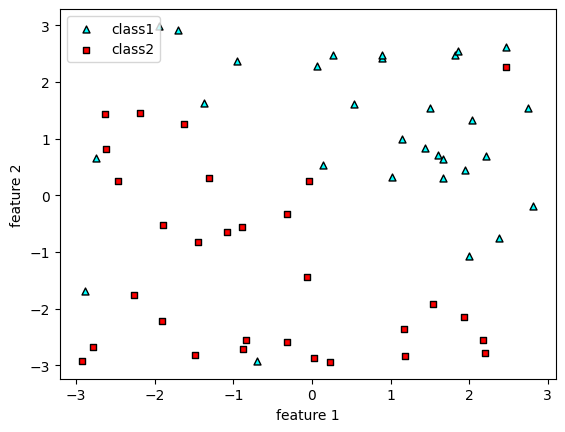

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

linear_data = pd.read_csv('/content/drive/MyDrive/AGST 892/Week5/linear.csv')
features = np.array(linear_data[['x_1', 'x_2']])
labels = np.array(linear_data['y'])
plot_points(features, labels,size = 25)

##Building linear kernels SVM

Accuracy: 0.9333333333333333


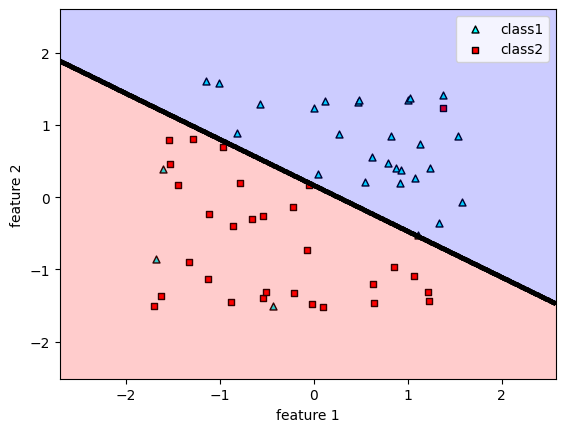

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Exercise to normalize the features
# Scale the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Exercise to use SVM package
# Train SVM with scaled features
svm_linear = SVC(kernel='linear')
svm_linear.fit(features_scaled, labels)

# Evaluate and plot
print("Accuracy:", svm_linear.score(features_scaled, labels))
plot_model(features_scaled, labels, svm_linear)


C = 0.01
Accuracy: 0.8833333333333333


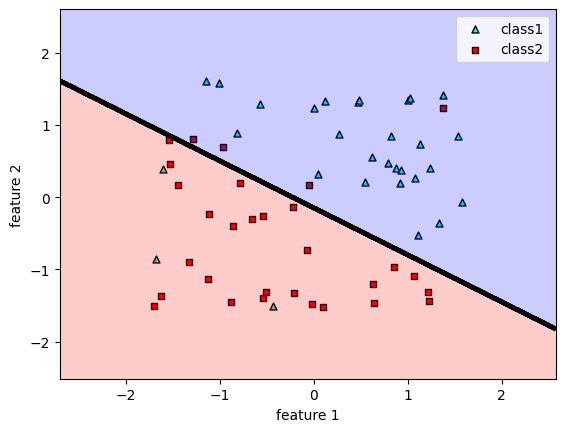

C = 100
Accuracy: 0.9166666666666666


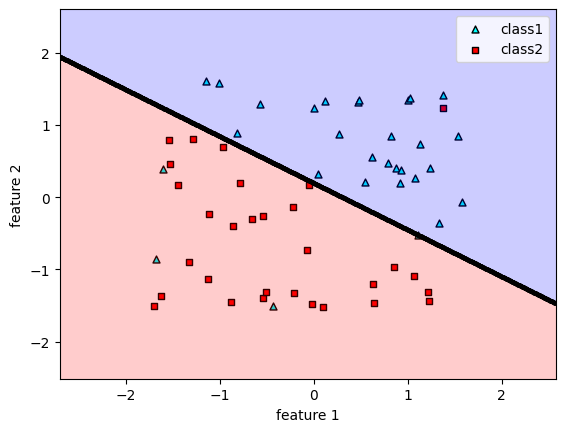

In [34]:
# C = 0.01
svm_c_001 = SVC(kernel='linear', C=0.01)
svm_c_001.fit(features_scaled, labels)
print("C = 0.01")
print("Accuracy:", svm_c_001.score(features_scaled, labels))
plot_model(features_scaled, labels, svm_c_001)

# C = 100
svm_c_100 = SVC(kernel='linear', C=100)
svm_c_100.fit(features_scaled, labels)
print("C = 100")
print("Accuracy:", svm_c_100.score(features_scaled, labels))
plot_model(features_scaled, labels, svm_c_100)

##Data Visualization

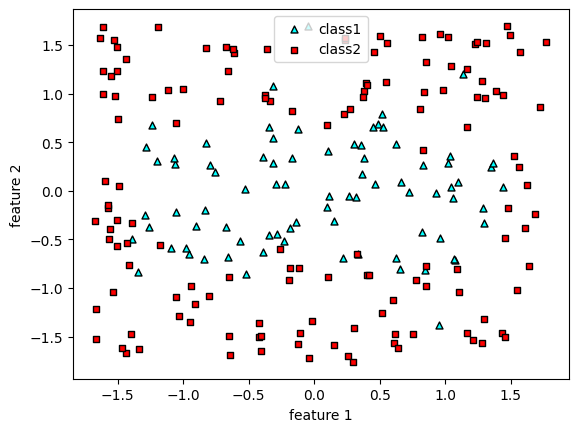

In [35]:
# Loading the two_circles dataset
import pandas as pd

two_circles_data = pd.read_csv('/content/drive/MyDrive/AGST 892/Week5/two_circles.csv')
features = np.array(two_circles_data[['x_1', 'x_2']])
labels = np.array(two_circles_data['y'])

# Scale the features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

plot_points(features_scaled, labels, 25)

##polynomial kernels

Polynomial kernel of degree = 2
Accuracy: 0.8818181818181818


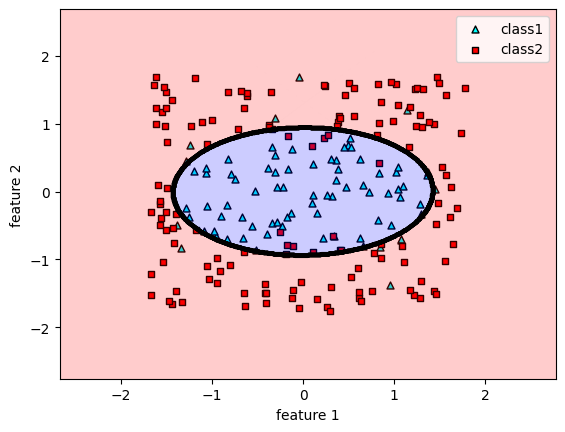

Polynomial kernel of degree = 4
Accuracy: 0.8409090909090909


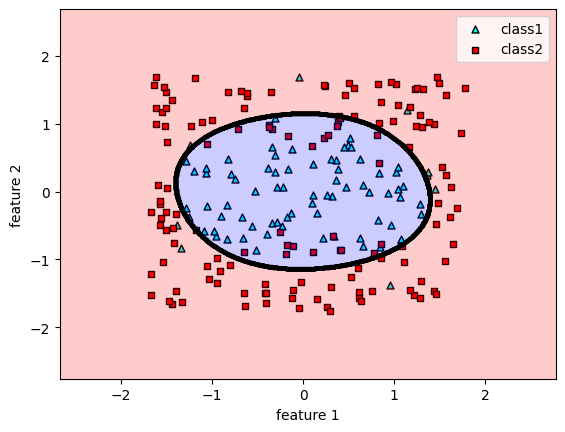

In [36]:
# Degree = 2
svm_degree_2 = SVC(kernel='poly', degree=2, gamma = 1)
svm_degree_2.fit(features_scaled, labels)
print("Polynomial kernel of degree = 2")
print("Accuracy:", svm_degree_2.score(features_scaled, labels))
plot_model(features_scaled, labels, svm_degree_2)

# Degree = 4
svm_degree_4 = SVC(kernel='poly', degree=4)
svm_degree_4.fit(features_scaled, labels)
print("Polynomial kernel of degree = 4")
print("Accuracy:", svm_degree_4.score(features_scaled, labels))
plot_model(features_scaled, labels, svm_degree_4)

##rbf kernels

Gamma = 0.1
Accuracy: 0.8227272727272728


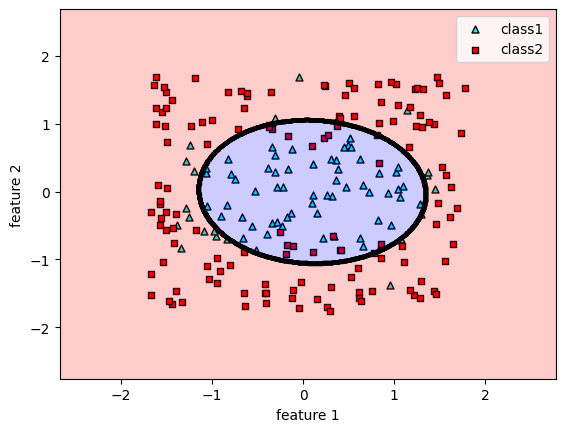

Gamma = 1
Accuracy: 0.8954545454545455


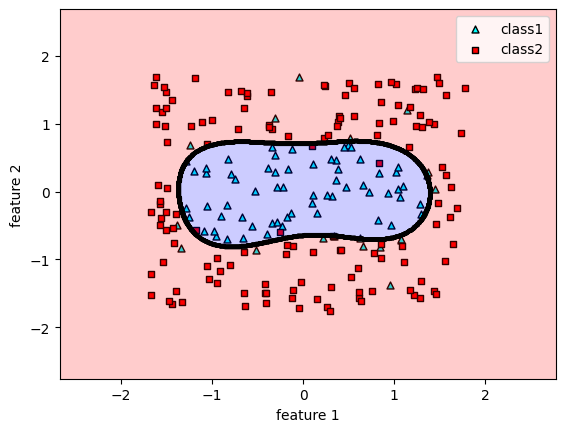

Gamma = 10
Accuracy: 0.9409090909090909


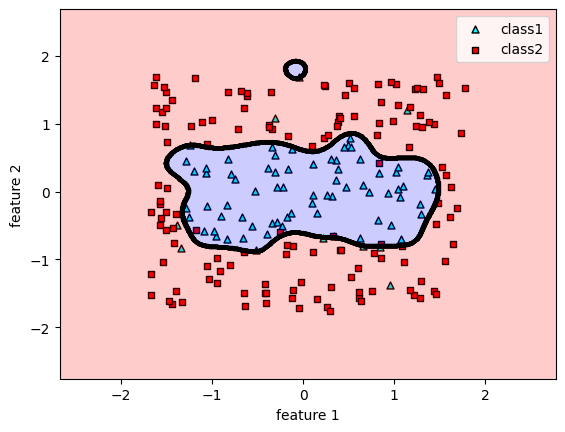

Gamma = 100
Accuracy: 0.9818181818181818


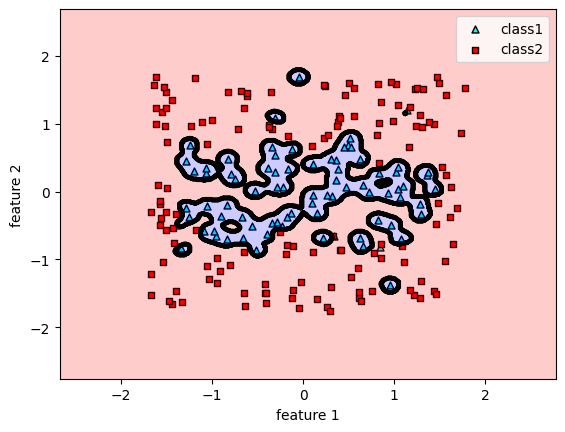

In [37]:
# gamma = 0.1
svm_gamma_01 = SVC(kernel='rbf', gamma=0.1)
svm_gamma_01.fit(features_scaled, labels)
print("Gamma = 0.1")
print("Accuracy:", svm_gamma_01.score(features_scaled, labels))
plot_model(features_scaled, labels, svm_gamma_01)

# gamma = 1
svm_gamma_1 = SVC(kernel='rbf', gamma=1)
svm_gamma_1.fit(features_scaled, labels)
print("Gamma = 1")
print("Accuracy:", svm_gamma_1.score(features_scaled, labels))
plot_model(features_scaled, labels, svm_gamma_1)

# gamma = 10
svm_gamma_10 = SVC(kernel='rbf', gamma=10)
svm_gamma_10.fit(features_scaled, labels)
print("Gamma = 10")
print("Accuracy:", svm_gamma_10.score(features_scaled, labels))
plot_model(features_scaled, labels, svm_gamma_10)

# gamma = 100
svm_gamma_100 = SVC(kernel='rbf', gamma=100)
svm_gamma_100.fit(features_scaled, labels)
print("Gamma = 100")
print("Accuracy:", svm_gamma_100.score(features_scaled, labels))
plot_model(features_scaled, labels, svm_gamma_100)

##GridSearchCV - tuning the hyper parameters

Best parameters found: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Best cross-validated accuracy: 0.8727272727272728


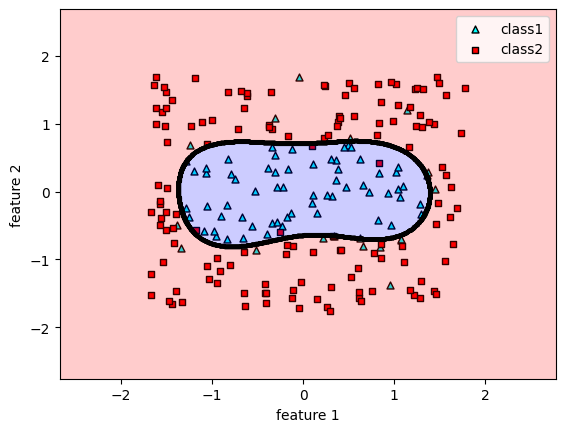

In [38]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Define the combinations of hyperparameters to try
param_grid = {
    'kernel': ['rbf'],
    'C': [0.01, 0.1, 1, 10],       # Regularization strength
    'gamma': [0.001, 0.01, 0.1, 1, 10],    # RBF kernel parameter
}

# Set up the SVC model
svm = SVC()

# GridSearchCV: cv: cross-validation
grid_search = GridSearchCV(svm, param_grid, cv=4, scoring='accuracy')

# Fit on training data
grid_search.fit(features_scaled, labels)

# Best model and parameters
print("Best parameters found:", grid_search.best_params_) # hyperparameters with the best CV performance
print("Best cross-validated accuracy:", grid_search.best_score_) # best mean validation accuracy from CV

# Optional: visualize with your plot_model function
best_svm = grid_search.best_estimator_
plot_model(features_scaled, labels, best_svm)


##pipline - sequentially apply a list of processing

Gamma = 1
Accuracy: 0.8954545454545455


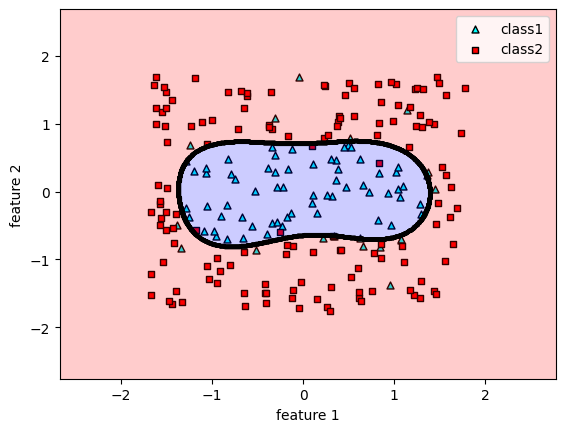

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Define pipeline with scaling and SVM
pipeline = Pipeline([
    ('scaler', StandardScaler()),      # Step 1: preprocessing - normalize the data
    ('svm', SVC(kernel='rbf', gamma=1))  # Step 2: rbf kernel SVM classifier
])

# Fit the pipeline
pipeline.fit(features, labels)

# Evaluate
print("Gamma = 1")
print("Accuracy:", pipeline.score(features, labels))

# Plot using the scaled features (extracted from the pipeline)
features_scaled = pipeline.named_steps['scaler'].transform(features)
plot_model(features_scaled, labels, pipeline.named_steps['svm'])


Best parameters found: {'svm__C': 1, 'svm__gamma': 1, 'svm__kernel': 'rbf'}
Best cross-validated accuracy: 0.8727272727272728


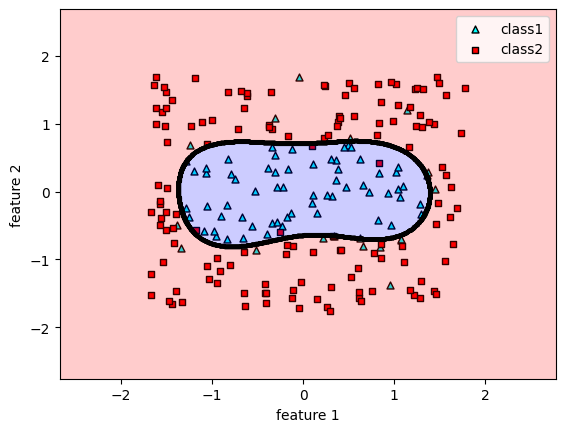

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Create pipeline with scaling and SVM
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

# Define parameter grid using pipeline syntax
param_grid = {
    'svm__kernel': ['rbf'],
    'svm__C': [0.01, 0.1, 1, 10],
    'svm__gamma': [0.001, 0.01, 0.1, 1, 10],
}

# Set up GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=4, scoring='accuracy')

# Fit on raw (unscaled) features — pipeline handles scaling
grid_search.fit(features, labels)

# Best model and parameters
print("Best parameters found:", grid_search.best_params_)
print("Best cross-validated accuracy:", grid_search.best_score_)

# Plot decision boundary using scaled features
features_scaled = grid_search.best_estimator_.named_steps['scaler'].transform(features)
best_svm = grid_search.best_estimator_.named_steps['svm']
plot_model(features_scaled, labels, best_svm)

#**Homework**
Dataset: Breast cancer Wisconsin (diagnostic) dataset https://www.kaggle.com/code/anandhuh/breast-cancer-prediction-accuracy-98-24/input

**Task**: Apply Logistic Regression and Support Vector Machine (SVM) to classify breast cancer cases as Benign (B) or Malignant (M).

**Requirements**:

* Split the data into train set and test set.
* write a report for all the experiments you conducted, including different parameters you tested.
* For lostic regression, you may explore different penalty type and regularization strength parameter (C). For SVM, you may experiment with different kernels and their corresponding parameters. At least two different settings need to be applied for both logistic regression and SVM.
* Compare the performance of the models and parameter settings using evaluation metrics such as accuracy, precision, recall, F1-score and the classification report. Finally identify which model and parameter configuration achieved the best performance.
* In addition, your report should also answer the following question: how logstic regression and SVM could be used in your research area? Please provide a detailed example by describing the problem and background, the predictor variables and the dependent variables.

You are required to submit a report document (pdf) and a colab notebook file (.ipynb).<br><br>



**Pre-Class Reading**:

* [Decision Tree](https://www.geeksforgeeks.org/machine-learning/decision-tree/)
* [Random Forest](https://www.geeksforgeeks.org/machine-learning/random-forest-algorithm-in-machine-learning/)
<br>

**Rubics**:

Logistic Regression (8 pts)
* parameter setting 1 (3pts)
* parameter setting 2 (3pts)
* performance (2pts)

SVM (8pts)
* parameter setting 1 (3pts)
* parameter setting 2 (3pts)
* performance (2pts)

Identify the best-performing model and parameter settings (2pts)

Additional Question (2pts)

In [3]:
#Task: Apply Logistic Regression and Support Vector Machine (SVM) to classify breast cancer cases as Benign (B) or Malignant (M).

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
file_path = "/content/drive/MyDrive/AGST 892/Week5/Breast Cancer Prediction.csv"
data = pd.read_csv(file_path)

# Display the first few rows and dataset info
data.head(), data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

(         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
 0    842302         M        17.99         10.38          122.80     1001.0   
 1    842517         M        20.57         17.77          132.90     1326.0   
 2  84300903         M        19.69         21.25          130.00     1203.0   
 3  84348301         M        11.42         20.38           77.58      386.1   
 4  84358402         M        20.29         14.34          135.10     1297.0   
 
    smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
 0          0.11840           0.27760          0.3001              0.14710   
 1          0.08474           0.07864          0.0869              0.07017   
 2          0.10960           0.15990          0.1974              0.12790   
 3          0.14250           0.28390          0.2414              0.10520   
 4          0.10030           0.13280          0.1980              0.10430   
 
    ...  texture_worst  perimeter_worst  area_wo

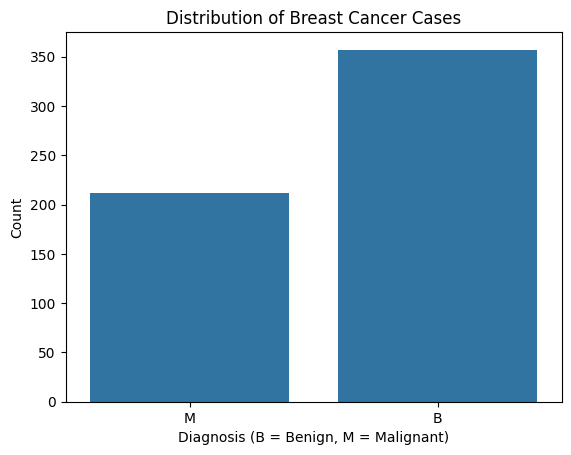

In [4]:
# Plot the class distribution

import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="diagnosis", data=data)
plt.title("Distribution of Breast Cancer Cases")
plt.xlabel("Diagnosis (B = Benign, M = Malignant)")
plt.ylabel("Count")
plt.show()


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Drop unnecessary columns
data_clean = data.drop(columns=["id", "Unnamed: 32"])

# Encode target variable (M=1, B=0)
# Most machine learning models (like Logistic Regression and SVM) can only work with numerical values, not strings.
# Therefore, we need to convert text labels into numbers
le = LabelEncoder()
data_clean["diagnosis"] = le.fit_transform(data_clean["diagnosis"])


# Split "x = features" and "y = target"
X = data_clean.drop(columns=["diagnosis"])
y = data_clean["diagnosis"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
#log_reg = LogisticRegression(C=1.5,max_iter=10000)
log_reg = LogisticRegression(C = 0.6, max_iter=10000)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)


print("Logistic Regression:")
print(classification_report(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))


Logistic Regression:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Confusion Matrix:
 [[72  0]
 [ 2 40]]


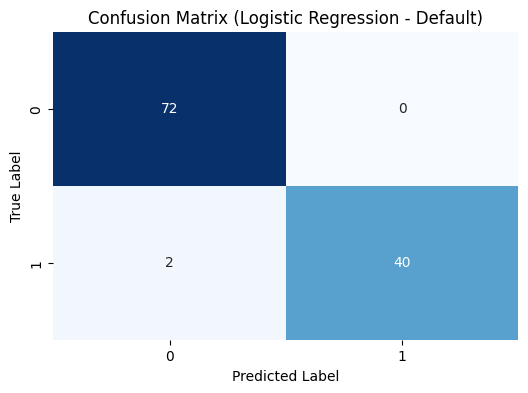

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Logistic Regression - Default)')
plt.show()


Logistic Regression (L1 Regularization):
              precision    recall  f1-score   support

           0       0.93      0.99      0.96        72
           1       0.97      0.88      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114

Confusion Matrix:
 [[71  1]
 [ 5 37]]


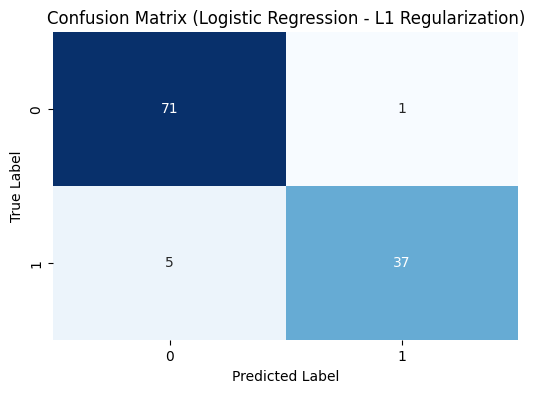

In [59]:
# L1 regularization (feature selection)
log_reg_l1 = LogisticRegression(C = 1.0, penalty="l1", solver="liblinear", max_iter=1000)
log_reg_l1.fit(X_train, y_train)
y_pred_log_l1 = log_reg_l1.predict(X_test)

print("\nLogistic Regression (L1 Regularization):")
print(classification_report(y_test, y_pred_log_l1))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log_l1))

cm_l1 = confusion_matrix(y_test, y_pred_log_l1)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_l1 , annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Logistic Regression - L1 Regularization)')
plt.show()

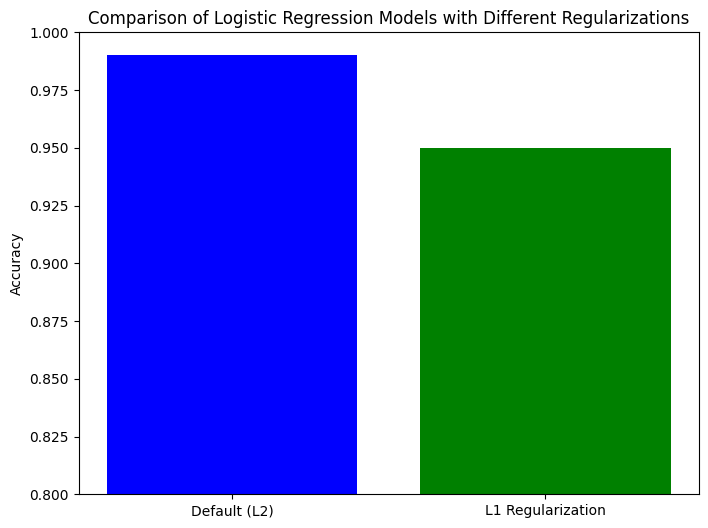

In [45]:
import matplotlib.pyplot as plt


accuracy_default = 0.99
accuracy_l1 = 0.95

labels = ['Default (L2)', 'L1 Regularization'] # Corrected labels list
accuracies = [accuracy_default, accuracy_l1] # Corrected accuracies list

plt.figure(figsize=(8, 6))
plt.bar(labels, accuracies, color=['blue', 'green']) # Adjusted colors to match the number of bars
plt.ylim(0.8, 1.0) # Set y-axis limits for better comparison
plt.ylabel('Accuracy')
plt.title('Comparison of Logistic Regression Models with Different Regularizations')
plt.show()


Support Vector Machine (RBF kernel, gamma=1):
              precision    recall  f1-score   support

           0       0.63      1.00      0.77        72
           1       0.00      0.00      0.00        42

    accuracy                           0.63       114
   macro avg       0.32      0.50      0.39       114
weighted avg       0.40      0.63      0.49       114

Confusion Matrix:
 [[72  0]
 [42  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


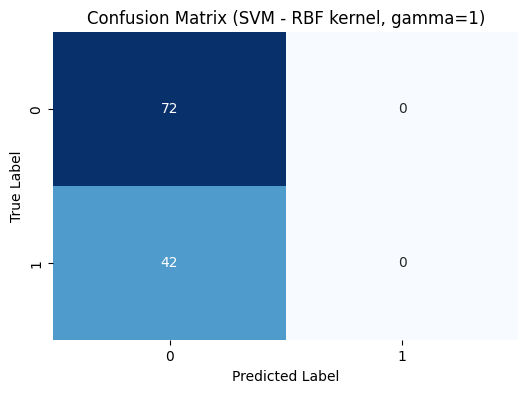


Support Vector Machine (RBF kernel, gamma=10):
              precision    recall  f1-score   support

           0       0.63      1.00      0.77        72
           1       0.00      0.00      0.00        42

    accuracy                           0.63       114
   macro avg       0.32      0.50      0.39       114
weighted avg       0.40      0.63      0.49       114

Confusion Matrix:
 [[72  0]
 [42  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


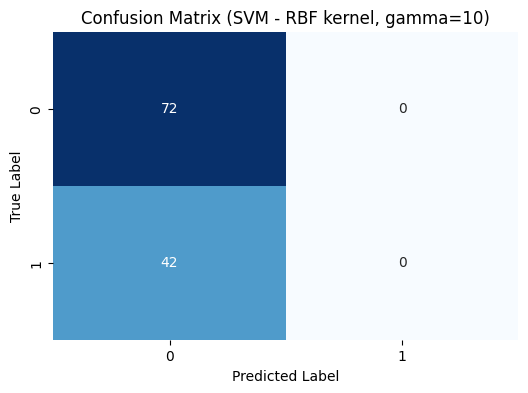

In [61]:
# SVM with RBF kernel and different gamma values

# gamma = 1
svm_rbf_gamma1 = SVC(kernel='rbf', gamma=1)
svm_rbf_gamma1.fit(X_train_scaled, y_train)
y_pred_svm_rbf_gamma1 = svm_rbf_gamma1.predict(X_test_scaled)

print("\nSupport Vector Machine (RBF kernel, gamma=1):")
print(classification_report(y_test, y_pred_svm_rbf_gamma1))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm_rbf_gamma1))

#print confusin matrix
cm_gamma1 = confusion_matrix(y_test, y_pred_svm_rbf_gamma1)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_gamma1, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (SVM - RBF kernel, gamma=1)')
plt.show()


# gamma = 10
svm_rbf_gamma10 = SVC(kernel='rbf', gamma=10)
svm_rbf_gamma10.fit(X_train_scaled, y_train)
y_pred_svm_rbf_gamma10 = svm_rbf_gamma10.predict(X_test_scaled)

print("\nSupport Vector Machine (RBF kernel, gamma=10):")
print(classification_report(y_test, y_pred_svm_rbf_gamma10))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm_rbf_gamma10))

#print confusin matrix
cm_gamma10 = confusion_matrix(y_test, y_pred_svm_rbf_gamma10)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_gamma10, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (SVM - RBF kernel, gamma=10)')
plt.show()


Support Vector Machine (Polynomial kernel, degree=2):
              precision    recall  f1-score   support

           0       0.78      0.96      0.86        72
           1       0.88      0.52      0.66        42

    accuracy                           0.80       114
   macro avg       0.83      0.74      0.76       114
weighted avg       0.81      0.80      0.78       114

Confusion Matrix:
 [[69  3]
 [20 22]]


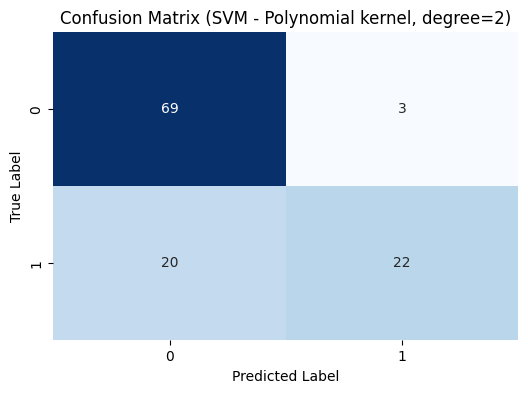


Support Vector Machine (Polynomial kernel, degree=3):
              precision    recall  f1-score   support

           0       0.85      1.00      0.92        72
           1       1.00      0.69      0.82        42

    accuracy                           0.89       114
   macro avg       0.92      0.85      0.87       114
weighted avg       0.90      0.89      0.88       114

Confusion Matrix:
 [[72  0]
 [13 29]]


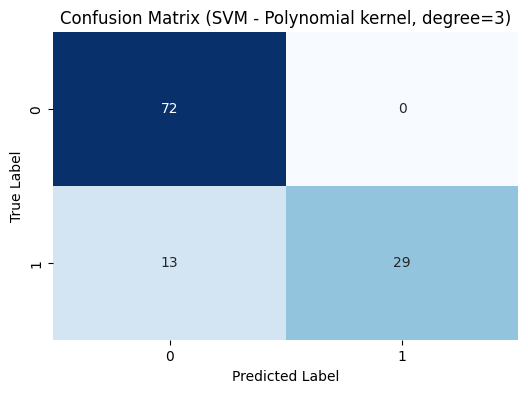

In [62]:
# SVM with Polynomial kernel and different degrees

# Degree = 2
svm_poly_degree2 = SVC(kernel='poly', degree=2, gamma='auto') # Using 'auto' gamma as a common practice
svm_poly_degree2.fit(X_train_scaled, y_train)
y_pred_svm_poly_degree2 = svm_poly_degree2.predict(X_test_scaled)

print("\nSupport Vector Machine (Polynomial kernel, degree=2):")
print(classification_report(y_test, y_pred_svm_poly_degree2))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm_poly_degree2))

#print confusin matrix
cm_degree2 = confusion_matrix(y_test, y_pred_svm_poly_degree2)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_degree2, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (SVM - Polynomial kernel, degree=2)')
plt.show()

# Degree = 3 (default)
svm_poly_degree3 = SVC(kernel='poly', degree=3, gamma='auto')
svm_poly_degree3.fit(X_train_scaled, y_train)
y_pred_svm_poly_degree3 = svm_poly_degree3.predict(X_test_scaled)

print("\nSupport Vector Machine (Polynomial kernel, degree=3):")
print(classification_report(y_test, y_pred_svm_poly_degree3))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm_poly_degree3))

#print confusin matrix
cm_degree3 = confusion_matrix(y_test, y_pred_svm_poly_degree3)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_degree3, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (SVM - Polynomial kernel, degree=3)')
plt.show()


Support Vector Machine (SVM):
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

Confusion Matrix:
 [[72  0]
 [ 4 38]]


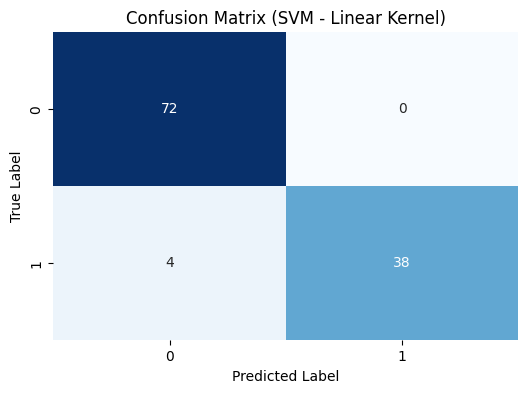

In [63]:
# Support Vector Machine (SVM), Linear Kernel
svm_clf = SVC(kernel="linear", probability=True)
svm_clf.fit(X_train_scaled, y_train)
y_pred_svm = svm_clf.predict(X_test_scaled)

# Evaluate models

print("\nSupport Vector Machine (SVM):")
print(classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

#print confusin matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (SVM - Linear Kernel)')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

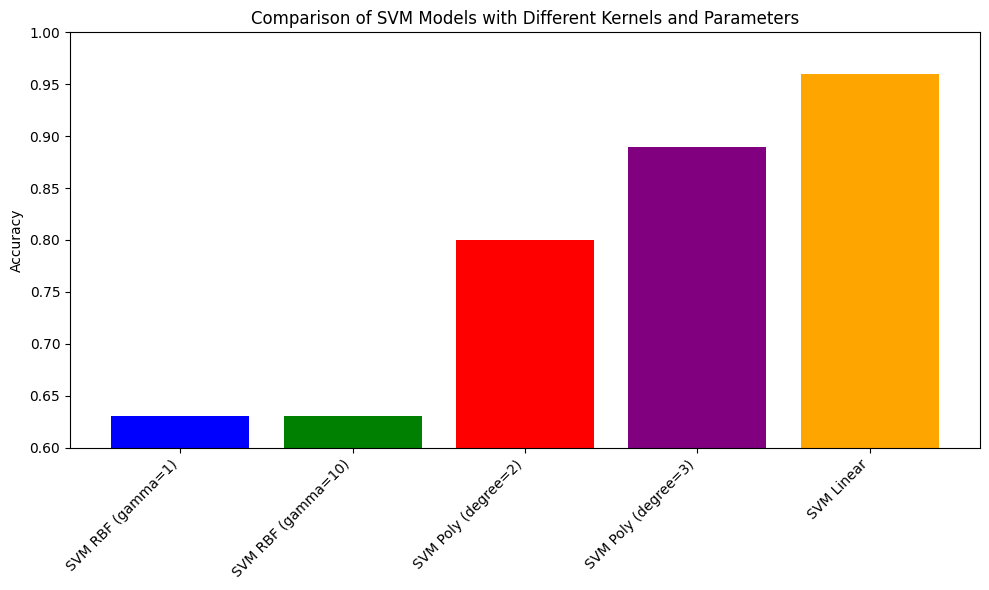

In [51]:
import matplotlib.pyplot as plt
import re # Import the regular expression module to parse the classification report

# Define a function to extract accuracy from the classification report string
def extract_accuracy(report_string):
    # Use regex to find the accuracy line and extract the accuracy value
    match = re.search(r'accuracy\s+(\d+\.\d+)', report_string)
    if match:
        return float(match.group(1))
    return None # Return None if accuracy is not found

# Get accuracy scores by extracting from the classification reports
# Assuming the previous cells generating these reports have been run
accuracy_svm_rbf_gamma1 = extract_accuracy(classification_report(y_test, y_pred_svm_rbf_gamma1))
accuracy_svm_rbf_gamma10 = extract_accuracy(classification_report(y_test, y_pred_svm_rbf_gamma10))
accuracy_svm_poly_degree2 = extract_accuracy(classification_report(y_test, y_pred_svm_poly_degree2))
accuracy_svm_poly_degree3 = extract_accuracy(classification_report(y_test, y_pred_svm_poly_degree3))
accuracy_svm_linear = extract_accuracy(classification_report(y_test, y_pred_svm))


labels = ['SVM RBF (gamma=1)', 'SVM RBF (gamma=10)', 'SVM Poly (degree=2)', 'SVM Poly (degree=3)', 'SVM Linear'] # Corrected labels list
accuracies = [accuracy_svm_rbf_gamma1, accuracy_svm_rbf_gamma10, accuracy_svm_poly_degree2, accuracy_svm_poly_degree3, accuracy_svm_linear] # Corrected accuracies list

# Remove None values in case any accuracy extraction failed
valid_accuracies = [acc for acc in accuracies if acc is not None]
valid_labels = [labels[i] for i, acc in enumerate(accuracies) if acc is not None]


plt.figure(figsize=(10, 6))
plt.bar(valid_labels, valid_accuracies, color=['blue', 'green', 'red', 'purple', 'orange']) # Adjusted colors
plt.ylim(0.6, 1.0) # Set y-axis limits for better comparison
plt.ylabel('Accuracy')
plt.title('Comparison of SVM Models with Different Kernels and Parameters')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

Comparison of Best Logistic Regression and Best SVM Models:

--- Best Logistic Regression (Default/L2) ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


--- Best Support Vector Machine (Linear Kernel) ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



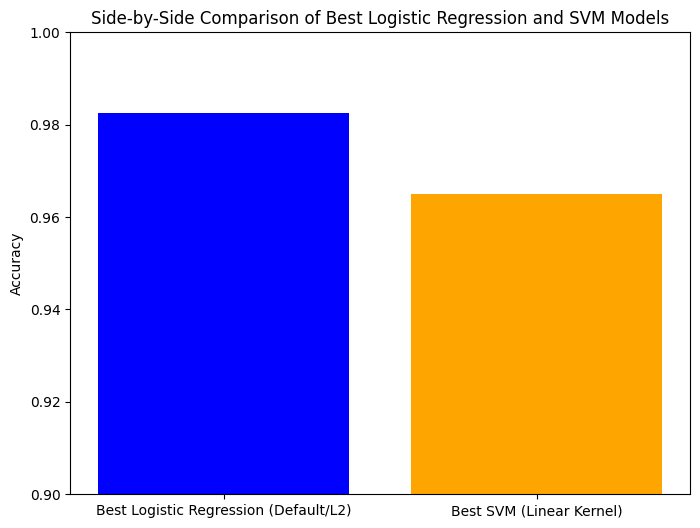

In [55]:
# Identify the best Logistic Regression model based on accuracy from previous outputs
best_log_reg_report = classification_report(y_test, y_pred_log) # Assuming default (L2) was slightly better or comparable and is a common choice

# Identify the best SVM model based on accuracy from previous outputs

best_svm_report = classification_report(y_test, y_pred_svm) # Assuming Linear SVM was the best performing or comparable

print("Comparison of Best Logistic Regression and Best SVM Models:")
print("\n--- Best Logistic Regression (Default/L2) ---")
print(best_log_reg_report)

print("\n--- Best Support Vector Machine (Linear Kernel) ---")
print(best_svm_report)

accuracy_best_log_reg = accuracy_score(y_test, y_pred_log) # Accuracy from the default Logistic Regression
accuracy_best_svm = accuracy_score(y_test, y_pred_svm) # Accuracy from the Linear SVM

labels = ['Best Logistic Regression (Default/L2)', 'Best SVM (Linear Kernel)']
accuracies = [accuracy_best_log_reg, accuracy_best_svm]

plt.figure(figsize=(8, 6))
plt.bar(labels, accuracies, color=['blue', 'orange'])
plt.ylim(0.9, 1.0) # Set y-axis limits for better comparison
plt.ylabel('Accuracy')
plt.title('Side-by-Side Comparison of Best Logistic Regression and SVM Models')
plt.show()